# Peer agreement vs paid AI judges on held-out NL→FOL data (T1)

**What this artifact tests.** You translate a sentence into first-order logic (NL→FOL) and have no gold formula. Can you
still tell whether the candidate formula says what the sentence says? The artifact's metric is **peer agreement**,
`c_score_align`: several systems formalise the same sentence, and a candidate scores as more likely *unfaithful* the less
it agrees with its peers, where agreement is z3 equivalence after predicate names are aligned. **T1** compares this
metric head-on with paid LLM judges on a held-out dataset **E** (8,507 real candidates, 700 sentences):

| comparator | what it is |
|---|---|
| `judge_cheap_disg` / `_orig` | gemini-2.5-flash-lite rubric-A JSON judge. `disg` means content words are replaced by nonce words (a contamination guard). |
| `judge_cheap2_disg` / `_orig` | gpt-4.1-nano P(YES) judge |
| `judge_strong_orig` | gemini-3.1-pro-preview frontier judge, scored on a 284-row frame only |
| `rt_*` | API round trip: FOL → English (flash-lite), then DeBERTa NLI / mpnet cosine against the sentence |
| `sc5_*` | API self-consistency: 5 nano samples, z3 equivalence modulo vocabulary |
| `S4_full_oof` | cross-fitted logistic stack of all 28 baselines |
| `p_peer_text` | PEER+TEXT fusion |

**Orientation:** every score is oriented so that **higher = more likely UNFAITHFUL**. The label is ERROR = 1 and
CORRECT = 0, obtained by prover-checked equivalence to the gold formula plus human-tier adjudication.

**What this notebook runs.** `method.py` is a stage dispatcher (`--stage prep | judges | sc_gen | verbalise | strong |
nli | sc_score | t1_analysis …`). The API and GPU stages need OpenRouter keys, a GPU and about $2.40, so they are not
re-run here. Their per-row outputs are the frozen `predict_*` columns in `full_method_out.json`. This notebook re-runs the
**`t1_analysis` stage**, the statistics core in `src/api_bar.py` and `src/analyse_T1.py`, with the original code:
- stratified and pooled AUROC;
- the sentence-cluster bootstrap, with paired deltas;
- criterion (a), the head-on test;
- the nested S4 gain, criterion (b);
- the frontier frame ratio, criterion (d);
- the complexity curves;
- the label-permutation placebos.

It runs on a **100-row, stratum-balanced subset** of the main population (R_AB, E_POOL, parseable; the full population
is n = 2,686 over 292 sentences). The subset's numbers are therefore noisy. The full-population values from the
artifact are shipped in the data file and printed alongside for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports

This cell keeps the original `method.py` import block, the `PYTHONHASHSEED` default and the loguru stdout sink. The
file sink to `logs/run.log` is dropped. The cell then adds the imports that `src/api_bar.py` and `src/analyse_T1.py`
use (numpy, `scipy.stats.rankdata`, sklearn inside functions), plus matplotlib for the plots.

In [2]:
from __future__ import annotations

import argparse
import asyncio
import hashlib
import json
import math
import os
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

os.environ.setdefault("PYTHONHASHSEED", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
sys.setrecursionlimit(10000)

from loguru import logger  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# src/api_bar.py + src/analyse_T1.py
import types
from typing import Callable, Sequence

import numpy as np
from scipy.stats import rankdata

# notebook: plots
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["method_name"], "| verdict of the full run:", data["metadata"]["verdict"])
print(data["metadata"]["subset"])
print("rows:", len(data["examples"]))
ex0 = data["examples"][0]
print("\nexample row:\n  text:", ex0["input"]["text"], "\n  fol :", ex0["input"]["candidate_fol"],
      "\n  system:", ex0["input"]["system"], "| label:", ex0["output"],
      "| c_score_align:", ex0["predict_c_score_align"], "| judge_cheap_disg:", ex0["predict_judge_cheap_disg"])

T1 head-on API bar on held-out dataset E | verdict of the full run: CONFIRMED
100 rows of the R_AB E_POOL PRIMARY population (n=2,686), <= 3 rows per sentence, 25 per source stratum, seed 0
rows: 100

example row:
  text: A fuel x is suitable for an engine y in a vehicle z if x meets the performance requirements of y and is compatible with the fuel system of z. 
  fol : ∀x∀y∀z (Fuel(x) ∧ Engine(y) ∧ Vehicle(z) → (Suitable(x, y, z) ↔ (MeetsPerformance(x, y) ∧ CompatibleWithFuelSystem(x, z)))) 
  system: G2:qwen/qwen3-235b-a22b-2507 | label: CORRECT | c_score_align: 1.0 | judge_cheap_disg: 0.05


## Configuration

All tunable parameters are set here. The original run used `B = 2000` sentence-cluster bootstrap resamples for every
AUROC and delta, `B = 1000` for the complexity bins, and 200 label-permutation placebo reps, with 5 GroupKFold splits
for the nested frontier-frame model. The values below were chosen to fit the notebook's time budget on the 100-row
subset.

In [5]:
B = 2000               # sentence-cluster bootstrap resamples per cell (original: 2000)
B_COMPLEXITY = 1000    # bootstrap resamples for the complexity-bin cells (original: 1000)
N_PLACEBO = 200       # label-permutation placebo reps (original: 200)
NESTED_FOLDS = 5    # GroupKFold splits (by sentence) for the nested frontier-frame model (original: 5)
FA_LEVEL = 0.10     # matched false-alarm operating point on CORRECT rows (original: 0.10)
BOOT_SEED = 0       # bootstrap seed (original: 0)

## 1. Statistics core (`src/api_bar.py`, verbatim)

- **`auroc`**: Mann–Whitney AUROC, with ties counted ½.
- **`strat_auroc`**: the *within-stratum* AUROC. Only (ERROR, CORRECT) pairs from the same source stratum count. The
  strata are L25, L20, EXC and CTRL: long sentences, exception sentences, and short FOLIO controls. This removes the
  part of the pooled AUROC that merely reflects stratum composition.
- **`ClusterBoot`**: resamples *sentences* with replacement. Every metric in a row set uses the identical resamples, so
  the deltas are paired.
- The file also defines the percentile CI, DeLong, the matched-FA threshold and recall at a threshold.

In [6]:
def auroc(y, s) -> float:
    """Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def tie_rate(y, s) -> float:
    """Share of (ERROR, CORRECT) pairs whose scores are exactly tied."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    vals, inv = np.unique(np.concatenate([pos, neg]), return_inverse=True)
    cp = np.bincount(inv[:len(pos)], minlength=len(vals))
    cn = np.bincount(inv[len(pos):], minlength=len(vals))
    return float((cp * cn).sum() / (len(pos) * len(neg)))


def strat_auroc(y, s, stratum) -> float:
    """Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    """Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired."""

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    """Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`)."""
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


def delong(y, s1, s2) -> dict:
    """DeLong paired test on pooled AUROC (secondary: ignores sentence clustering)."""
    from scipy.stats import norm
    y = np.asarray(y)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)
    pos, neg = s1[y == 1], s1[y == 0]
    pos2, neg2 = s2[y == 1], s2[y == 0]
    m, n = len(pos), len(neg)
    if m < 2 or n < 2:
        return {"z": None, "p": None}

    def comps(p, q):
        # V10_i = mean_j [p_i > q_j] + .5[p_i == q_j]; vectorised by ranks
        allv = np.concatenate([p, q])
        r_all = rankdata(allv)
        r_p = rankdata(p)
        r_q = rankdata(q)
        v10 = (r_all[:len(p)] - r_p) / len(q)
        v01 = 1.0 - (r_all[len(p):] - r_q) / len(p)
        return v10, v01
    a10, a01 = comps(pos, neg)
    b10, b01 = comps(pos2, neg2)
    d = a10.mean() - b10.mean()
    s10 = np.cov(np.vstack([a10, b10]))
    s01 = np.cov(np.vstack([a01, b01]))
    var = (s10[0, 0] + s10[1, 1] - 2 * s10[0, 1]) / m + (s01[0, 0] + s01[1, 1] - 2 * s01[0, 1]) / n
    if var <= 0:
        return {"z": None, "p": None}
    z = d / math.sqrt(var)
    return {"z": float(z), "p": float(2 * (1 - norm.cdf(abs(z))))}


def matched_fa_threshold(neg_vals, fa: float = 0.10) -> float:
    """Threshold t = the (1-fa) quantile of the scores of CORRECT rows (flag = score > t)."""
    return float(np.quantile(np.asarray(neg_vals, float), 1 - fa))


def recall_at(y, s, t) -> dict:
    y = np.asarray(y)
    s = np.asarray(s, float)
    f = s > t
    tp = int((f & (y == 1)).sum())
    fp = int((f & (y == 0)).sum())
    return {"threshold": float(t), "recall": tp / max(1, int(y.sum())), "fa": fp / max(1, int((y == 0).sum())),
            "precision": tp / max(1, tp + fp), "n_flag": int(f.sum())}


# analyse_T1.py calls these as AB.<name> (`from . import api_bar as AB`); a namespace keeps that code unchanged
AB = types.SimpleNamespace(auroc=auroc, tie_rate=tie_rate, strat_auroc=strat_auroc, ClusterBoot=ClusterBoot, boot_ci=boot_ci,
                           paired_boot=paired_boot, delong=delong, matched_fa_threshold=matched_fa_threshold, recall_at=recall_at)

## 2. The per-row table and labelled cells (`src/analyse_T1.py`, verbatim)

- **`Table`** holds the oriented value of every metric for every row. API columns carry a status: `ok`, `fallback`,
  `fail` or `missing`.
- **`Cell`** is a labelled row set: keys, labels `y`, sentence clusters and strata. One `ClusterBoot` is shared by
  every metric in the cell. `Cell.delta(a, b, stat)` is the paired bootstrap test behind every "Δ [CI]" in the paper.
  It uses only rows where both metrics have a value.

The one change from the original: `B` comes from the config cell, not the hard-coded 2000.

In [7]:
STRATA = ["L25", "L20", "EXC", "CTRL"]
LONG = ("L25", "L20", "EXC")
CHALLENGERS = ["c_score_align", "g_score", "nf_c_score", "p_peer_text", "p_text"]
API_BARS = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig"]
LOCAL_BAR = "L:judge_local_qwen8b_disg"
# B = 2000  -> set in the config cell
TIEBREAK_EPS = 1e-9


def _u01(k: str) -> float:
    return int(hashlib.sha1(("tiebreak|" + k).encode()).hexdigest()[:12], 16) / 16 ** 12


class Table:
    """Per-row values of every metric (oriented), with the status-aware accessor .vec(metric, keys)."""

    def __init__(self, rows, api, fail_fill):
        self.rows = rows
        self.by = {x["canonical_key"]: x for x in rows}
        self.api = api
        self.fail_fill = fail_fill
        self.extra: dict[str, dict] = {}

    def value(self, m: str, k: str):
        if m in self.extra:
            return self.extra[m].get(k)
        if m in self.api:
            return self.api[m]["v"].get(k)
        x = self.by[k]
        if m.startswith("L:"):
            st = x.get(m + "__status")
            v = x.get(m)
            if st == "fail":
                return self.fail_fill.get(m[2:], 1.0) if v is None else v
            return v
        return x.get(m)

    def status(self, m: str, k: str) -> str:
        if m in self.api:
            return self.api[m]["st"].get(k, "missing")
        if m.startswith("L:"):
            return self.by[k].get(m + "__status") or "na"
        return "ok" if self.value(m, k) is not None else "missing"

    def vec(self, m: str, keys) -> np.ndarray:
        return np.array([np.nan if (v := self.value(m, k)) is None else float(v) for k in keys], float)

    def vec_tb(self, m: str, keys) -> np.ndarray:
        """vec() + a label-free, seeded tie-breaker (TIEBREAK_EPS x U[0,1) from sha1(canonical_key)) for the matched-FA
        operating points: quantised scores put >10% of CORRECT rows at the maximum, so 'flag = s > q90' never fires
        without it (randomised test; AUROCs never use it)."""
        return self.vec(m, keys) + TIEBREAK_EPS * np.array([_u01(k) for k in keys])

    def has(self, m: str) -> bool:
        return m in self.extra or m in self.api or any(self.value(m, x["canonical_key"]) is not None for x in self.rows[:500])


class Cell:
    """A labelled row set (keys, y, clusters, strata) with one bootstrap shared by every metric of the cell."""

    def __init__(self, name, keys, y, T: Table, b=None):
        b = B if b is None else b  # notebook: default from the config cell (original default b=B=2000)
        self.name, self.keys, self.y = name, list(keys), np.asarray(y)
        self.cl = np.array([T.by[k]["sentence_id"] for k in self.keys])
        self.h = np.array([T.by[k]["source_stratum"] for k in self.keys])
        self.T = T
        self.b = b
        self._boots: dict = {}
        self._cache: dict = {}

    def boot(self, mask):
        key = hashlib.sha1(mask.tobytes()).hexdigest()
        if key not in self._boots:
            self._boots[key] = AB.ClusterBoot(list(self.cl[mask]), b=self.b, seed=BOOT_SEED)
        return key, self._boots[key]

    def series(self, m, mask, stat):
        mk, cb = self.boot(mask)
        ck = (mk, m, stat)
        if ck not in self._cache:
            s = self.T.vec(m, self.keys)[mask]
            y, h = self.y[mask], self.h[mask]
            f = (lambda yy, ss, hh: AB.auroc(yy, ss)) if stat == "pooled" else AB.strat_auroc
            pt = f(y, s, h)
            bs = np.array([f(y[ix], s[ix], h[ix]) for ix in cb.idx])
            self._cache[ck] = (pt, bs)
        return self._cache[ck]

    def mask_for(self, *ms):
        mask = np.ones(len(self.keys), bool)
        for m in ms:
            mask &= ~np.isnan(self.T.vec(m, self.keys))
        return mask

    def n_info(self, mask):
        y = self.y[mask]
        return {"n": int(mask.sum()), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()),
                "n_sentences": int(len(set(self.cl[mask])))}

    def metric(self, m, stat="pooled", mask=None):
        mask = self.mask_for(m) if mask is None else mask
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pt, bs = self.series(m, mask, stat)
        return {"auroc": pt, "ci": AB.boot_ci(bs), **self.n_info(mask)}

    def delta(self, a, c, stat="strat"):
        mask = self.mask_for(a, c)
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pa, ba = self.series(a, mask, stat)
        pc, bc = self.series(c, mask, stat)
        d = ba - bc
        d = d[~np.isnan(d)]
        out = {"a": a, "b": c, "stat": stat, "auroc_a": pa, "auroc_b": pc, "delta": pa - pc, "ci": AB.boot_ci(d),
               "p_one_sided_le0": float(np.mean(d <= 0)) if len(d) else None, "se": float(np.std(d)) if len(d) else None,
               **self.n_info(mask)}
        if stat == "pooled" and mask.sum() <= 6000:
            y = self.y[mask]
            dl = AB.delong(y, self.T.vec(a, self.keys)[mask], self.T.vec(c, self.keys)[mask])
            out["delong_z"], out["delong_p"] = dl["z"], dl["p"]
        return out


def testable(y, cl) -> bool:
    y = np.asarray(y)
    cl = np.asarray(cl)
    return int(y.sum()) >= 50 and int((y == 0).sum()) >= 50 and len(set(cl[y == 1])) >= 25 and len(set(cl[y == 0])) >= 25


def describe(cell: Cell, m: str, thr: dict, cost_item: dict) -> dict:
    mask = cell.mask_for(m)
    y = cell.y[mask]
    s = cell.T.vec(m, cell.keys)[mask]
    from sklearn.metrics import average_precision_score
    out = cell.metric(m, "pooled", mask)
    if out.get("untestable"):
        return out
    out["strat"] = cell.metric(m, "strat", mask)
    out["auprc"] = float(average_precision_score(y, s))
    out["prevalence"] = float(y.mean())
    out["tie_rate"] = AB.tie_rate(y, s)
    if m in thr and thr[m] is not None:
        out["at_frozen_threshold"] = AB.recall_at(y, s, thr[m])
    stb = cell.T.vec_tb(m, cell.keys)[mask]
    out["at_FA0.10_E"] = AB.recall_at(y, stb, AB.matched_fa_threshold(stb[y == 0], FA_LEVEL))
    out["at_FA0.10_E"]["share_correct_at_max"] = float(np.mean(s[y == 0] == np.max(s)))
    out["usd_per_item"] = cost_item.get(m)
    st = Counter(cell.T.status(m, k) for k in cell.keys)
    out["status_counts"] = dict(st)
    return out

## 3. Building the table from the loaded data

In the original, `run()` builds `rows` with `join_T1.base_rows()` from dataset E and exp 5 / exp 6 files. It builds the
API columns with `join_T1.api_columns()` from `results/scores/*.jsonl`, and the S4 out-of-fold stacks with
`s4_nesting()`. Here the same three objects are built from the frozen per-row `predict_*` columns in the data file:
- **consensus and pilot metrics** become plain row fields;
- **local exp-6 metrics** get the `L:` prefix;
- **API metrics** go into `api[m] = {"v": …, "st": …}`;
- **S4 stacks** go into `T.extra`.

The **labels** (`regimes`) come from the `output` field. R_AB is tiers A and B; R_A is tier A only.

In [8]:
CONSENSUS_COLS = ["c_score_align", "g_score", "nf_c_score", "nf_g_score", "p_peer_text", "p_text", "l2_bow", "l3_z3"]
API_COLS = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig", "judge_strong_orig",
            "judge_strong_disg", "judge_cheap_disg_vfb", "rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra",
            "rt_nli_min_alt", "rt_embed_cos", "sc5_eq_frac", "sc5_entropy"]
S4_COLS = ["S4_full_oof", "S4_local_oof", "S4_full_plus_c_score_align_oof", "PT_refit_oof", "PT_refit_NF_oof"]

rows, api, s4cols = [], {c: {"v": {}, "st": {}} for c in API_COLS}, {c: {} for c in S4_COLS}
regimes = {"R_AB": {}, "R_A": {}}
for e in data["examples"]:
    k = e["metadata_canonical_key"]
    x = {"canonical_key": k, "exp6_row_key": e["metadata_exp6_row_key"], "item_id": e["metadata_item_id"],
         "sentence_id": e["metadata_sentence_id"], "pool": e["metadata_pool"], "parse_ok": e["metadata_parse_ok"],
         "strata": e["metadata_strata"], "source_stratum": e["metadata_strata"]["source_stratum"],
         "sysvar": e["metadata_sysvar"], "text": e["input"]["text"], "fol": e["input"]["candidate_fol"]}
    for c in CONSENSUS_COLS:
        x[c] = e.get("predict_" + c)
    for f, v in e.items():
        if f.startswith("predict_local_"):
            x["L:" + f[len("predict_local_"):]] = v
    rows.append(x)
    for c in API_COLS:
        v = e.get("predict_" + c)
        if v is not None:
            api[c]["v"][k] = v
        api[c]["st"][k] = "ok" if v is not None else "missing"
    for c in S4_COLS:
        s4cols[c][k] = e.get("predict_" + c)
    y = 1 if e["output"] == "ERROR" else 0
    if e["metadata_in_R_AB"]:
        regimes["R_AB"][k] = y
    if e["metadata_in_R_A"]:
        regimes["R_A"][k] = y

T = Table(rows, api, fail_fill={})
for c, v in s4cols.items():  # original: s4_nesting() returns these OOF columns, then T.extra[c] = v
    T.extra[c] = v
REF = data["reference_full_population"]
A: dict = {"api_columns": sorted(api)}
print(f"{len(rows)} rows, {len(api)} API columns, {len(s4cols)} S4 stacks; R_AB labels {len(regimes['R_AB'])}, R_A labels {len(regimes['R_A'])}")

100 rows, 15 API columns, 5 S4 stacks; R_AB labels 100, R_A labels 36


## 4. Population and criterion (a): head-on against the cheap API judges

`keys_for()` is verbatim. It selects the rows of a regime by pool, parseability and stratum. The main population is
**R_AB, E_POOL, parseable**.

The loop is the original `(a)` loop. For each cell (pooled, long pool, each stratum, R_A L20+EXC), it computes the
stratified and pooled AUROC of every challenger and comparator, and every paired challenger − comparator delta. The
coverage cell and the contested-label cells need rows that are not in the demo subset, so they are left out.

**Criterion (a)** holds when all three of these hold:
- the stratified Δ(c_score_align − judge_cheap_disg) CI lies above 0 on R_AB;
- the same holds on the long pool;
- Δ > 0 on R_A L20+EXC.

In [9]:
def keys_for(regime, pool="E_POOL", primary=True, strata=None, extra=None):
    lab = regimes[regime]
    ks = [x["canonical_key"] for x in rows if x["canonical_key"] in lab and x["pool"] == pool
          and (x["parse_ok"] or not primary) and (strata is None or x["source_stratum"] in strata)
          and (extra is None or extra(x))]
    return ks, np.array([lab[k] for k in ks])
P, yP = keys_for("R_AB")
A["population"] = {"n": len(P), "n_error": int(yP.sum()), "n_correct": int(len(yP) - yP.sum()),
                   "n_sentences": len({T.by[k]["sentence_id"] for k in P})}
logger.info(f"population {A['population']}   (full run: {REF['population']})")

t0 = time.time()
bars = [b for b in API_BARS if b in api]
cellP = Cell("R_AB pooled", P, yP, T)
pooled_bar = {b: cellP.metric(b, "pooled")["auroc"] for b in bars if not cellP.metric(b, "pooled").get("untestable")}
best = max(pooled_bar, key=pooled_bar.get) if pooled_bar else None
A["bar"] = {"primary": "judge_cheap_disg", "available": True, "api_bars_present": bars, "BEST_API_CHEAP": best, "pooled_auroc": pooled_bar}
bar_list = bars + [LOCAL_BAR]

cells = {}
cells["R_AB pooled"] = cellP
k, y = keys_for("R_AB", strata=LONG)
cells["R_AB long (L25+L20+EXC)"] = Cell("R_AB long", k, y, T)
for h in STRATA:
    k, y = keys_for("R_AB", strata=(h,))
    cells[f"R_AB {h}"] = Cell(f"R_AB {h}", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC"))
cells["R_A L20+EXC"] = Cell("R_A L20+EXC", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC", "CTRL"))
cells["R_A L20+EXC+CTRL"] = Cell("R_A L20+EXC+CTRL", k, y, T)
# (COVERAGE / CONTESTED_* / ALL_TIERS cells need rows outside the demo subset — omitted)
A["a_head_on"] = {}
for cname, cell in cells.items():
    out = {"n": len(cell.keys), "n_error": int(cell.y.sum()), "n_correct": int(len(cell.y) - cell.y.sum()),
           "n_sentences": len(set(cell.cl)), "testable": testable(cell.y, cell.cl), "deltas": {}, "metrics": {}}
    stats = ["strat", "pooled"] if cname not in [f"R_AB {h}" for h in STRATA] else ["pooled"]
    for m in CHALLENGERS + bar_list:
        out["metrics"][m] = {st: cell.metric(m, st) for st in stats}
    for a in CHALLENGERS:
        for bb in bar_list:
            for st in stats:
                out["deltas"][f"{a} - {bb} [{st}]"] = cell.delta(a, bb, st)
    A["a_head_on"][cname] = out
    logger.info(f"(a) {cname}: n={out['n']} " + ", ".join(
        f"{a}-cheap_disg[{stats[0]}]={out['deltas'].get(f'{a} - judge_cheap_disg [{stats[0]}]', {}).get('delta', float('nan')):.3f}"
        for a in ("c_score_align", "p_peer_text")))


def crit_a(bar):
    c1 = A["a_head_on"]["R_AB pooled"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c2 = A["a_head_on"]["R_AB long (L25+L20+EXC)"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c3 = A["a_head_on"]["R_A L20+EXC"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    ok1 = bool(c1.get("ci") and c1["ci"][0] is not None and c1["ci"][0] > 0)
    ok2 = bool(c2.get("ci") and c2["ci"][0] is not None and c2["ci"][0] > 0)
    ok3 = bool(c3.get("delta") is not None and c3["delta"] > 0)
    return {"bar": bar, "R_AB_strat": {k_: c1.get(k_) for k_ in ("delta", "ci", "n", "p_one_sided_le0")}, "R_AB_strat_CI_gt0": ok1,
            "long_strat": {k_: c2.get(k_) for k_ in ("delta", "ci", "n")}, "long_strat_CI_gt0": ok2,
            "R_A_L20EXC": {k_: c3.get(k_) for k_ in ("delta", "ci", "n")}, "R_A_sign_gt0": ok3, "holds": ok1 and ok2 and ok3}
A["criterion_a"] = {b: crit_a(b) for b in bar_list}
logger.info(f"(a) done in {time.time()-t0:.1f}s")

ca = A["criterion_a"]["judge_cheap_disg"]
print("\nCriterion (a) vs judge_cheap_disg on the DEMO SUBSET")
print(f"  R_AB strat delta  {ca['R_AB_strat']['delta']:+.3f}  CI {np.round(ca['R_AB_strat']['ci'], 3)}  n={ca['R_AB_strat']['n']}")
print(f"  long strat delta  {ca['long_strat']['delta']:+.3f}  CI {np.round(ca['long_strat']['ci'], 3)}  n={ca['long_strat']['n']}")
d3 = ca['R_A_L20EXC']['delta']
print(f"  R_A L20+EXC delta {'untestable' if d3 is None else f'{d3:+.3f}'}  n={ca['R_A_L20EXC']['n']}")
print(f"  holds on subset: {ca['holds']}")
r = REF["criterion_a"]
print(f"FULL RUN (n={r['R_AB_strat']['n']}): R_AB strat {r['R_AB_strat']['delta']:+.3f} {np.round(r['R_AB_strat']['ci'], 3)}, "
      f"long {r['long_strat']['delta']:+.3f} {np.round(r['long_strat']['ci'], 3)}, R_A L20+EXC {r['R_A_L20EXC']['delta']:+.3f} -> {r['status']}")

12:51:54|INFO   |population {'n': 100, 'n_error': 54, 'n_correct': 46, 'n_sentences': 36}   (full run: {'n': 2686, 'n_error': 1822, 'n_correct': 864, 'n_sentences': 292})


12:52:00|INFO   |(a) R_AB pooled: n=100 c_score_align-cheap_disg[strat]=0.092, p_peer_text-cheap_disg[strat]=0.015


12:52:06|INFO   |(a) R_AB long (L25+L20+EXC): n=75 c_score_align-cheap_disg[strat]=0.098, p_peer_text-cheap_disg[strat]=0.039


12:52:07|INFO   |(a) R_AB L25: n=25 c_score_align-cheap_disg[pooled]=0.042, p_peer_text-cheap_disg[pooled]=0.101


12:52:08|INFO   |(a) R_AB L20: n=25 c_score_align-cheap_disg[pooled]=-0.015, p_peer_text-cheap_disg[pooled]=-0.004


...

12:52:10|INFO   |(a) R_AB CTRL: n=25 c_score_align-cheap_disg[pooled]=0.075, p_peer_text-cheap_disg[pooled]=-0.055


12:52:14|INFO   |(a) R_A L20+EXC: n=21 c_score_align-cheap_disg[strat]=0.377, p_peer_text-cheap_disg[strat]=0.038


12:52:19|INFO   |(a) R_A L20+EXC+CTRL: n=32 c_score_align-cheap_disg[strat]=0.349, p_peer_text-cheap_disg[strat]=0.060


12:52:19|INFO   |(a) done in 25.3s



Criterion (a) vs judge_cheap_disg on the DEMO SUBSET
  R_AB strat delta  +0.092  CI [-0.053  0.244]  n=100
  long strat delta  +0.098  CI [-0.066  0.278]  n=75
  R_A L20+EXC delta +0.377  n=21
  holds on subset: False
FULL RUN (n=2686): R_AB strat +0.099 [0.049 0.146], long +0.116 [0.07  0.163], R_A L20+EXC +0.299 -> CONFIRMED


## 5. Criterion (b): does consensus add signal to the stack of all 28 baselines?

`S4_full_oof` is a cross-fitted logistic stack over every baseline: judges, round-trip NLI, SC-5, the pilot structural
metrics and the local judges. `S4_full_plus_c_score_align_oof` is the same stack with the consensus score added. The
original `s4_nesting()` refits both on the full 2,686-row population with `folds_E.json`. Refitting on 100 rows would be
meaningless, so the demo uses the **frozen out-of-fold predictions** of those fits. The nested gain is then the same
`Cell.delta` paired bootstrap as in the original.

In [10]:
A["b_s4"] = {"nested_strat": cellP.delta("S4_full_plus_c_score_align_oof", "S4_full_oof", "strat"),
             "nested_pooled": cellP.delta("S4_full_plus_c_score_align_oof", "S4_full_oof", "pooled"),
             "c_alone_minus_S4_full_strat": cellP.delta("c_score_align", "S4_full_oof", "strat")}
for cname in ("R_AB pooled", "R_AB long (L25+L20+EXC)", "R_A L20+EXC"):
    cell = cells[cname]
    for a in ("S4_full_oof", "S4_local_oof", "S4_full_plus_c_score_align_oof", "PT_refit_oof"):
        if a in T.extra:
            for bb in ("judge_cheap_disg", "c_score_align", "p_peer_text"):
                if bb in api or bb in CHALLENGERS:
                    for st in ("strat", "pooled"):
                        A["a_head_on"][cname]["deltas"][f"{a} - {bb} [{st}]"] = cell.delta(a, bb, st)
bs = A["b_s4"]
for k_, v in bs.items():
    print(f"  {k_:32s} delta {v['delta']:+.3f}  CI {np.round(v['ci'], 3)}  ({v['auroc_a']:.3f} vs {v['auroc_b']:.3f}, n={v['n']})")
rb = REF["criterion_b"]
print(f"FULL RUN: nested strat {rb['strat']['delta']:+.3f} {np.round(rb['strat']['ci'], 3)}, permutation-null p95 {rb['null_p95_strat']:.3f} -> {rb['status']}")

  nested_strat                     delta -0.022  CI [-0.101  0.053]  (0.808 vs 0.830, n=100)
  nested_pooled                    delta -0.029  CI [-0.08   0.017]  (0.798 vs 0.826, n=100)
  c_alone_minus_S4_full_strat      delta -0.064  CI [-0.188  0.03 ]  (0.766 vs 0.830, n=100)
FULL RUN: nested strat +0.039 [0.021 0.057], permutation-null p95 0.009 -> CONFIRMED


## 6. Per-metric description on the main population

`describe()` is verbatim. For each metric it reports:
- pooled and stratified AUROC with the cluster-bootstrap CI;
- AUPRC;
- the tie rate;
- recall at the frozen threshold, and recall at a matched false-alarm rate of 10%, with a label-free tie-breaker.

Per-item costs are taken from the full run's cost ledger, because the subset has no API spend of its own.

In [11]:
thr = {"judge_cheap_disg": 0.5, "judge_cheap_orig": 0.5, "judge_cheap2_disg": 0.5, "judge_cheap2_orig": 0.5,
       "judge_strong_orig": 0.5, "judge_strong_disg": 0.5, "p_peer_text": data["metadata"]["thresholds"]["consensus_PT"]["fused"],
       "p_text": data["metadata"]["thresholds"]["consensus_PT"]["text"], LOCAL_BAR: 0.5}
# $/item from the full run (results/api_cost_ledger.json; consensus = peer-pool generation spend / candidate + z3 CPU)
cost_item = {"c_score_align": 1.2e-4, "p_peer_text": 1.2e-4, "judge_strong_orig": 3.65e-3}
desc_metrics = CHALLENGERS + ["l2_bow", "l3_z3"] + bar_list + \
    ["rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_nli_min_alt", "rt_embed_cos", "sc5_eq_frac", "sc5_entropy"] + \
    ["L:rt_nli_min_local", "L:sc5_local_eq_frac", "L:judge_local_qwen8b_orig", "L:judge_local_llama8b_disg", "L:parse_fail",
     "L:pilot_rerun_jacc"] + [c for c in s4cols if c.endswith("_oof")]
t0 = time.time()
A["metrics_R_AB"] = {m: describe(cellP, m, thr, cost_item) for m in desc_metrics}
logger.info(f"describe done in {time.time()-t0:.1f}s")
print(f"{'metric':34s} {'pooled':>7s} {'strat':>7s} {'AUPRC':>6s} {'ties':>5s} {'rec@FA.10':>9s}")
for m, d in A["metrics_R_AB"].items():
    if d.get("untestable"):
        print(f"{m:34s} untestable (n={d['n']})")
        continue
    print(f"{m:34s} {d['auroc']:7.3f} {d['strat']['auroc']:7.3f} {d['auprc']:6.3f} {d['tie_rate']:5.2f} {d['at_FA0.10_E']['recall']:9.2f}")

12:52:37|INFO   |describe done in 11.5s


metric                              pooled   strat  AUPRC  ties rec@FA.10
c_score_align                        0.738   0.766  0.742  0.13      0.48
g_score                              0.740   0.743  0.701  0.19      0.33
nf_c_score                           0.737   0.746  0.724  0.16      0.31
p_peer_text                          0.687   0.689  0.735  0.00      0.41
p_text                               0.600   0.577  0.676  0.04      0.30
l2_bow                               0.577   0.551  0.631  0.23      0.26
l3_z3                                0.588   0.615  0.660  0.17      0.28
judge_cheap_disg                     0.697   0.674  0.666  0.26      0.31
judge_cheap_orig                     0.646   0.645  0.682  0.39      0.35
judge_cheap2_disg                    0.664   0.664  0.682  0.01      0.22
judge_cheap2_orig                    0.696   0.677  0.734  0.00      0.33
L:judge_local_qwen8b_disg            0.716   0.713  0.739  0.15      0.44
rt_nli_min                           0

## 7. Criterion (d): the frontier judge on its frame

The frontier judge, gemini-3.1-pro-preview with the original view, was scored only on a pre-registered 284-row frame.
The frame rows are the rows with a `judge_strong_orig` value. The criterion compares the consensus AUROC with the
frontier AUROC as a ratio, and also fits a nested model (`nested_frame`, verbatim):
- a 5-fold GroupKFold by sentence;
- a logistic regression on [strong_orig + c] vs [strong_orig].

(d) holds when either condition is met:
- ratio ≥ 0.95 at ≤ 10% of the cost;
- the nested gain CI lies above 0.

The original's inverse-probability-weighted AUROC needs frame inclusion probabilities that are not in the subset, so it
is left out.

In [12]:
def nested_frame(cell, ks, y, T):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    so = T.vec("judge_strong_orig", ks)
    sc = T.vec("c_score_align", ks)
    mk = ~np.isnan(so) & ~np.isnan(sc)
    yy, g = y[mk], cell.cl[mk]
    X1 = so[mk][:, None]
    X2 = np.column_stack([so[mk], sc[mk]])
    o1, o2 = np.zeros(len(yy)), np.zeros(len(yy))
    for tr, te in GroupKFold(n_splits=NESTED_FOLDS).split(X1, yy, g):
        for X, o in ((X1, o1), (X2, o2)):
            mu, sd = X[tr].mean(0), X[tr].std(0)
            sd[sd == 0] = 1
            clf = LogisticRegression(C=1.0, max_iter=2000).fit((X[tr] - mu) / sd, yy[tr])
            o[te] = clf.predict_proba((X[te] - mu) / sd)[:, 1]
    cb = AB.ClusterBoot(list(g), b=B, seed=BOOT_SEED)
    r = AB.paired_boot(yy, o2, o1, cb, "pooled")
    return {"delta": r["delta"], "ci": r["ci"], "auroc_with_c": r["a"], "auroc_strong_only": r["b"], "n": int(mk.sum())}


# frame = one row per frame item (original: data/frontier_frame.json rows; here: rows scored by the frontier judge)
item_to_keys = defaultdict(list)
for x in T.rows:
    if x["pool"] == "E_POOL" and x["parse_ok"] and T.value("judge_strong_orig", x["canonical_key"]) is not None:
        item_to_keys[x["item_id"]].append(x["canonical_key"])
lab = regimes["R_AB"]
ks = [sorted(v)[0] for _, v in sorted(item_to_keys.items()) if any(k_ in lab for k_ in v)]
fy = np.array([lab[k_] for k_ in ks])
fcell = Cell("frame", ks, fy, T)
D = {"n_frame_rows": len(ks), "n_error": int(fy.sum()), "n_correct": int(len(fy) - fy.sum()), "metrics": {}}
for m in ["c_score_align", "p_peer_text", "nf_c_score", "judge_strong_orig", "judge_cheap_disg", "judge_cheap_orig", "S4_full_oof", LOCAL_BAR]:
    D["metrics"][m] = fcell.metric(m, "pooled")
best_view = "judge_strong_orig"
mk = fcell.mask_for("c_score_align", best_view)
pa, ba = fcell.series("c_score_align", mk, "pooled")
pb, bb = fcell.series(best_view, mk, "pooled")
ratio_b = ba / bb
D["ratio"] = {"best_frontier_view": best_view, "ratio": pa / pb, "ci": AB.boot_ci(ratio_b), "auroc_c": pa, "auroc_frontier": pb,
              "n": int(mk.sum()), "delta": fcell.delta("c_score_align", best_view, "pooled")}
D["nested_frame"] = nested_frame(fcell, ks, fy, T)
cost_ok = cost_item["c_score_align"] <= 0.10 * cost_item["judge_strong_orig"]
ratio_ok = D["ratio"]["ratio"] >= 0.95
nest_ok = bool(D["nested_frame"]["ci"][0] is not None and D["nested_frame"]["ci"][0] > 0)
D["criterion_d"] = {"ratio_ge_0.95": ratio_ok, "cost_le_0.10x": cost_ok, "nested_CI_gt0": nest_ok,
                    "holds": (ratio_ok and cost_ok) or nest_ok, "ratio": D["ratio"]["ratio"], "ratio_ci": D["ratio"]["ci"]}
A["d_frontier"] = D
print(f"frame rows in subset: {D['n_frame_rows']} ({D['n_error']} ERROR / {D['n_correct']} CORRECT)")
print(f"  AUROC c_score_align {pa:.3f} vs frontier {pb:.3f} -> ratio {D['ratio']['ratio']:.3f} CI {np.round(D['ratio']['ci'], 3)}")
nf = D["nested_frame"]
print(f"  nested [strong+c] - [strong]: {nf['delta']:+.3f} CI {np.round(nf['ci'], 3)}")
print(f"  cost/item: consensus ${cost_item['c_score_align']:.1e} vs frontier ${cost_item['judge_strong_orig']:.2e} (<=10%: {cost_ok})")
print(f"  criterion (d) on subset: {D['criterion_d']['holds']}")
rf = REF["frame_ratio"]
print(f"FULL RUN (frame n={rf['n']}): ratio {rf['ratio']:.3f} {np.round(rf['ci'], 3)} (AUROC {rf['auroc_c']:.3f} vs {rf['auroc_frontier']:.3f}) -> {REF['criterion_d']['status']}")

frame rows in subset: 52 (25 ERROR / 27 CORRECT)
  AUROC c_score_align 0.706 vs frontier 0.703 -> ratio 1.004 CI [0.865 1.198]
  nested [strong+c] - [strong]: +0.006 CI [-0.049  0.061]
  cost/item: consensus $1.2e-04 vs frontier $3.65e-03 (<=10%: True)
  criterion (d) on subset: True
FULL RUN (frame n=284): ratio 0.957 [0.887 1.034] (AUROC 0.710 vs 0.741) -> CONFIRMED


## 8. (f) How reliability changes with sentence complexity

`complexity()` is verbatim. It bins the main population by four variables and computes the pooled AUROC of each metric
per bin, plus Δ(c_score_align − judge_cheap_disg):
- word count;
- the number of conditions;
- the number of quantifiers;
- nesting depth, split into tertiles.

On the full run, the consensus advantage is concentrated in long, conditioned and exception sentences. It has no
advantage below 12 words or at ≤ 1 condition. A bin needs at least 10 rows with both labels; on the 100-row subset some
bins fall below that and are reported as untestable.

In [13]:
BINS = {"words": [(0, 12, "<12"), (12, 20, "12-19"), (20, 25, "20-24"), (25, 35, "25-34"), (35, 10 ** 6, ">=35")],
        "n_conditions": [(0, 2, "<=1"), (2, 3, "2"), (3, 4, "3"), (4, 10 ** 6, "4+")],
        "n_quant": [(0, 2, "0-1"), (2, 3, "2"), (3, 10 ** 6, "3+")]}


def complexity(T, P, yP, api):
    mets = ["c_score_align", "nf_c_score", "p_peer_text"] + [b for b in API_BARS if b in api] + \
        [m for m in ("S4_full_oof", "sc5_eq_frac", "rt_nli_min") if m in api or m in T.extra] + [LOCAL_BAR]
    depth = np.array([T.by[k]["strata"]["depth"] for k in P], float)
    q = np.quantile(depth, [1 / 3, 2 / 3])
    out = {}
    for var, bins in list(BINS.items()) + [("depth", [(-1, q[0] + 1e-9, f"<={q[0]:g}"), (q[0] + 1e-9, q[1] + 1e-9, f"({q[0]:g},{q[1]:g}]"),
                                                     (q[1] + 1e-9, 10 ** 6, f">{q[1]:g}")]), ("exception_type", None)]:
        res = {}
        if bins is None:
            vals = [str(T.by[k]["strata"].get("exception_type")) for k in P]
            groups = sorted(set(vals))
            idx_of = {gname: [i for i, v in enumerate(vals) if v == gname] for gname in groups}
        else:
            vv = np.array([T.by[k]["strata"][var] for k in P], float)
            idx_of = {lab: list(np.where((vv >= lo) & (vv < hi))[0]) for lo, hi, lab in bins}
        for lab, ix in idx_of.items():
            ks = [P[i] for i in ix]
            y = yP[ix]
            cell = Cell(f"{var}:{lab}", ks, y, T, b=B_COMPLEXITY)
            r = {"n": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "testable": testable(y, cell.cl),
                 "metrics": {}}
            if len(ks) >= 10 and 0 < y.sum() < len(y):
                for m in mets:
                    r["metrics"][m] = cell.metric(m, "pooled")
                if "judge_cheap_disg" in api:
                    r["delta_c_minus_cheapdisg"] = cell.delta("c_score_align", "judge_cheap_disg", "pooled")
            res[lab] = r
        out[var] = res
    return out


t0 = time.time()
A["f_complexity"] = complexity(T, P, yP, api)
logger.info(f"(f) complexity done in {time.time()-t0:.1f}s")
for var in ("words", "n_conditions"):
    print(f"\n{var}:")
    for lab_, r in A["f_complexity"][var].items():
        dd = r.get("delta_c_minus_cheapdisg")
        if not dd or dd.get("untestable"):
            print(f"  {lab_:>6s} n={r['n']:3d}  untestable on subset")
            continue
        print(f"  {lab_:>6s} n={r['n']:3d}  c_score_align {dd['auroc_a']:.3f}  judge_cheap_disg {dd['auroc_b']:.3f}  delta {dd['delta']:+.3f}")

12:52:48|INFO   |(f) complexity done in 9.5s



words:
     <12 n= 24  c_score_align 0.906  judge_cheap_disg 0.711  delta +0.195
   12-19 n= 23  c_score_align 0.671  judge_cheap_disg 0.571  delta +0.099
   20-24 n= 28  c_score_align 0.661  judge_cheap_disg 0.733  delta -0.072
   25-34 n= 24  c_score_align 0.654  judge_cheap_disg 0.607  delta +0.046
    >=35 n=  1  untestable on subset

n_conditions:
     <=1 n= 32  c_score_align 0.883  judge_cheap_disg 0.742  delta +0.141
       2 n=  6  untestable on subset
       3 n= 18  c_score_align 0.856  judge_cheap_disg 0.625  delta +0.231
      4+ n= 44  c_score_align 0.652  judge_cheap_disg 0.723  delta -0.072


## 9. Placebos: the test must fail on shuffled labels

This block is verbatim from `run()`. Labels are permuted `N_PLACEBO` times:
- the pooled AUROC of `c_score_align` should fall to about 0.5;
- the stratified Δ(c − judge_cheap_disg) should centre on 0.

In [14]:
rng = np.random.default_rng(0)
ca = T.vec("c_score_align", P)
jd = T.vec("judge_cheap_disg", P) if "judge_cheap_disg" in api else None
sh = [AB.auroc(rng.permutation(yP), ca) for _ in range(N_PLACEBO)]
A["placebo"] = {"shuffled_label_auroc_c_score_align": float(np.mean(sh))}
if jd is not None:
    m_ = ~np.isnan(jd)
    shd = []
    for _ in range(N_PLACEBO):
        yy = rng.permutation(yP)
        shd.append(AB.strat_auroc(yy[m_], ca[m_], cellP.h[m_]) - AB.strat_auroc(yy[m_], jd[m_], cellP.h[m_]))
    A["placebo"]["shuffled_label_strat_delta_c_minus_cheapdisg"] = {"mean": float(np.mean(shd)), "p2.5": float(np.percentile(shd, 2.5)),
                                                                    "p97.5": float(np.percentile(shd, 97.5))}
print(json.dumps(A["placebo"], indent=1))

{
 "shuffled_label_auroc_c_score_align": 0.5005766908212561,
 "shuffled_label_strat_delta_c_minus_cheapdisg": {
  "mean": 6.173238432766182e-05,
  "p2.5": -0.1755536274070756,
  "p97.5": 0.17636871613485852
 }
}


## 10. Results

The table below sets the AUROCs on the demo subset beside the full-population values stored in the data file. Four
plots follow:
1. stratified AUROC per metric, with bootstrap CIs;
2. a forest plot of the paired stratified deltas, c_score_align − each comparator;
3. AUROC by sentence length;
4. AUROC by number of conditions.

The subset's CIs are wide because it has only about 36 sentence clusters. The full run's conclusions rest on 292.

**Reading the subset honestly.** With 100 rows, the point estimates land near the full-run values:
- c_score_align's stratified AUROC is about 0.74–0.77 against about 0.64–0.68 for the cheap judges;
- the Δ versus judge_cheap_disg is about +0.09.

The subset's bootstrap CIs, however, can straddle 0. Its S4 stacks are the full-population out-of-fold predictions
evaluated on only 100 rows, so the nested gain of criterion (b) does not reproduce here; on the full population it is
+0.039 [0.021, 0.057]. The confirmatory verdict (CONFIRMED) comes from the full population, whose values are printed
beside each subset number.

metric                             subset strat subset pooled FULL strat FULL pooled
c_score_align                             0.766         0.738      0.741       0.782
g_score                                   0.743         0.740      0.694       0.748
nf_c_score                                0.746         0.737      0.686       0.743
p_peer_text                               0.689         0.687      0.753       0.790
p_text                                    0.577         0.600      0.670       0.693
judge_cheap_disg                          0.674         0.697      0.642       0.696
judge_cheap_orig                          0.645         0.646      0.623       0.635
judge_cheap2_disg                         0.664         0.664      0.644       0.681
judge_cheap2_orig                         0.677         0.696      0.653       0.700
L:judge_local_qwen8b_disg                 0.713         0.716      0.674       0.710
S4_full_oof                               0.830         0.826    

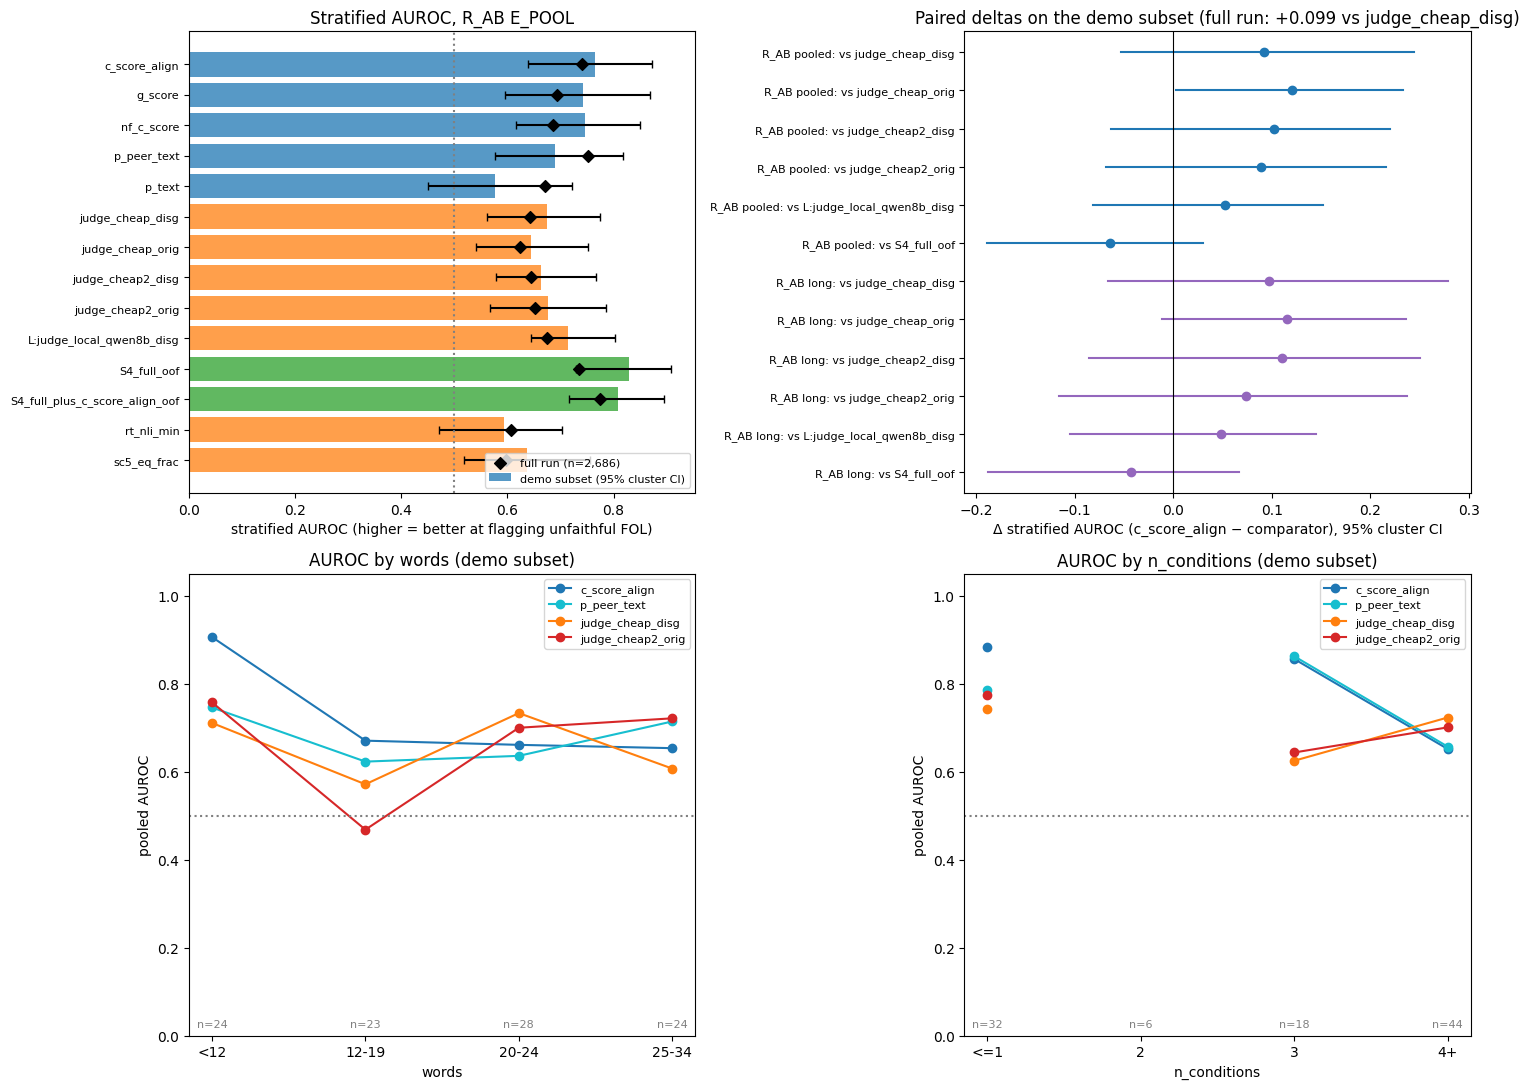

In [15]:
show = CHALLENGERS + bar_list + ["S4_full_oof", "S4_full_plus_c_score_align_oof", "rt_nli_min", "sc5_eq_frac"]
print(f"{'metric':34s} {'subset strat':>12s} {'subset pooled':>13s} {'FULL strat':>10s} {'FULL pooled':>11s}")
for m in show:
    d = A["metrics_R_AB"].get(m, {})
    fr = REF["auroc_R_AB"].get(m, {})
    fs = fr.get("strat"); fp = fr.get("pooled")
    ss = d.get("strat", {}).get("auroc") if not d.get("untestable") else None
    sp = d.get("auroc")
    fmt = lambda v: f"{v:.3f}" if v is not None else "  -  "
    print(f"{m:34s} {fmt(ss):>12s} {fmt(sp):>13s} {fmt(fs):>10s} {fmt(fp):>11s}")

print("\nCriteria on the demo subset:  (a)", A["criterion_a"]["judge_cheap_disg"]["holds"],
      "| (b) nested CI>0:", bool(A["b_s4"]["nested_strat"]["ci"][0] is not None and A["b_s4"]["nested_strat"]["ci"][0] > 0),
      "| (d)", A["d_frontier"]["criterion_d"]["holds"])
print("Full run verdict:", REF["overall"], "| a:", REF["criterion_a"]["status"], "| b:", REF["criterion_b"]["status"], "| d:", REF["criterion_d"]["status"])

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
# (1) stratified AUROC per metric with CI; full-run value as a marker
ax = axes[0, 0]
ms = [m for m in show if not A["metrics_R_AB"].get(m, {}).get("untestable")]
vals = [A["metrics_R_AB"][m]["strat"]["auroc"] for m in ms]
cis = [A["metrics_R_AB"][m]["strat"]["ci"] for m in ms]
err = np.array([[v - c[0], c[1] - v] for v, c in zip(vals, cis)]).T
col = ["tab:blue" if m in CHALLENGERS else ("tab:green" if m.startswith("S4") else "tab:orange") for m in ms]
yy_ = np.arange(len(ms))
ax.barh(yy_, vals, xerr=err, color=col, alpha=0.75, capsize=3, label="demo subset (95% cluster CI)")
full = [REF["auroc_R_AB"].get(m, {}).get("strat") for m in ms]
ax.scatter([f if f is not None else np.nan for f in full], yy_, marker="D", color="k", zorder=3, label="full run (n=2,686)")
ax.set_yticks(yy_); ax.set_yticklabels(ms, fontsize=8); ax.invert_yaxis()
ax.axvline(0.5, color="grey", ls=":")
ax.set_xlabel("stratified AUROC (higher = better at flagging unfaithful FOL)"); ax.set_title("Stratified AUROC, R_AB E_POOL")
ax.legend(fontsize=8, loc="lower right")
# (2) forest: c_score_align - comparator [strat], R_AB pooled and long pool
ax = axes[0, 1]
labels_, pts, los, his, cc = [], [], [], [], []
for cname, colr in (("R_AB pooled", "tab:blue"), ("R_AB long (L25+L20+EXC)", "tab:purple")):
    for bb in bar_list + ["S4_full_oof"]:
        d = A["a_head_on"][cname]["deltas"].get(f"c_score_align - {bb} [strat]") or \
            (cells[cname].delta("c_score_align", bb, "strat") if bb in T.extra else None)
        if not d or d.get("untestable"):
            continue
        labels_.append(f"{cname.split(' (')[0]}: vs {bb}"); pts.append(d["delta"]); los.append(d["ci"][0]); his.append(d["ci"][1]); cc.append(colr)
yy_ = np.arange(len(pts))
for i in range(len(pts)):
    ax.plot([los[i], his[i]], [yy_[i], yy_[i]], color=cc[i]); ax.plot(pts[i], yy_[i], "o", color=cc[i])
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(yy_); ax.set_yticklabels(labels_, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("Δ stratified AUROC (c_score_align − comparator), 95% cluster CI")
ax.set_title(f"Paired deltas on the demo subset (full run: +{REF['criterion_a']['R_AB_strat']['delta']:.3f} vs judge_cheap_disg)")
# (3)/(4) complexity curves
for ax, var in ((axes[1, 0], "words"), (axes[1, 1], "n_conditions")):
    res = A["f_complexity"][var]
    labs = list(res)
    for m, colr in (("c_score_align", "tab:blue"), ("p_peer_text", "tab:cyan"), ("judge_cheap_disg", "tab:orange"), ("judge_cheap2_orig", "tab:red")):
        v = [res[l]["metrics"].get(m, {}).get("auroc", np.nan) if res[l]["metrics"] else np.nan for l in labs]
        ax.plot(labs, v, "o-", color=colr, label=m)
    for i, l in enumerate(labs):
        ax.annotate(f"n={res[l]['n']}", (i, 0.02), ha="center", fontsize=8, color="grey")
    ax.axhline(0.5, color="grey", ls=":")
    ax.set_ylim(0, 1.05); ax.set_xlabel(var); ax.set_ylabel("pooled AUROC"); ax.set_title(f"AUROC by {var} (demo subset)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()